# Medical Insurance Cost Prediction — Multiple Linear Regression

**Dataset:** [Kaggle - Medical Cost Personal Insurance](https://www.kaggle.com/datasets/mirichoi0218/insurance)

**Objective:** Predict medical insurance `charges` from personal and health-related
features (age, sex, BMI, children, smoker, region) using Multiple Linear Regression.

**Structure:** One section per assignment task (Task 1 → Task 5). All imports are
consolidated in the setup cell below; each task builds on variables created by the
previous one, so run the notebook top to bottom.

## Setup

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.float_format", lambda x: f"{x:.2f}")

---
## Task 1: Data Understanding (2 Marks)

1. Load the dataset using Pandas.
2. Display the first five records.
3. Identify numerical features, categorical features, and the target variable.

In [18]:
df = pd.read_csv("data/insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,16884.92
1,18,male,33.77,1,no,southeast,1725.55
2,28,male,33.00,3,no,southeast,4449.46
3,33,male,22.70,0,no,northwest,21984.47
4,32,male,28.88,0,no,northwest,3866.86


In [19]:
print(f"Shape: {df.shape}\n")
df.info()

Shape: (1338, 7)

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


### Identify feature types

In [20]:
target_variable = "charges"

numerical_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
numerical_features.remove(target_variable)
categorical_features = df.select_dtypes(include=["object"]).columns.tolist()

print("Numerical features   :", numerical_features)
print("Categorical features :", categorical_features)
print("Target variable      :", target_variable)

Numerical features   : ['age', 'bmi', 'children']
Categorical features : ['sex', 'smoker', 'region']
Target variable      : charges


C:\Users\Suhani\AppData\Local\Temp\ipykernel_21668\3832491711.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(include=["object"]).columns.tolist()


---
## Task 2: Data Preprocessing (2 Marks)

1. Check for missing values.
2. Encode categorical variables (`sex`, `smoker`, `region`).
3. Split the dataset into 80% training and 20% testing.

### 1. Check for missing values

In [21]:
missing = df.isnull().sum()
print(missing)
print(f"\nTotal missing values: {missing.sum()}")

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Total missing values: 0


### 2. Encode categorical variables

- `sex` and `smoker` are binary → label-encoded as 0/1.
- `region` has 4 categories → one-hot encoded with `drop_first=True` to avoid the
  dummy-variable trap (multicollinearity).

In [22]:
df_encoded = df.copy()
df_encoded["sex"] = df_encoded["sex"].map({"female": 0, "male": 1})
df_encoded["smoker"] = df_encoded["smoker"].map({"no": 0, "yes": 1})
df_encoded = pd.get_dummies(df_encoded, columns=["region"], drop_first=True)

df_encoded.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.90,0,1,16884.92,False,False,True
1,18,1,33.77,1,0,1725.55,False,True,False
2,28,1,33.00,3,0,4449.46,False,True,False
3,33,1,22.70,0,0,21984.47,True,False,False
4,32,1,28.88,0,0,3866.86,True,False,False


### 3. Train/test split (80/20)

In [23]:
X = df_encoded.drop(columns=["charges"])   # features
y = df_encoded["charges"]                  # target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (1070, 8)
X_test shape : (268, 8)
y_train shape: (1070,)
y_test shape : (268,)


---
## Task 3: Model Development (3 Marks)

Build a Multiple Linear Regression model using `age`, `sex`, `bmi`, `children`,
`smoker`, `region` as features and `charges` as the target. Train on the training
split and predict charges for the test split.

In [24]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Intercept:", model.intercept_)

Intercept: -11931.21905032667


### Inspect model coefficients

In [25]:
coeff_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_
}).sort_values(by="Coefficient", key=abs, ascending=False)

coeff_df

,Feature,Coefficient
4,smoker,23651.13
7,region_southwest,-809.80
6,region_southeast,-657.86
3,children,425.28
5,region_northwest,-370.68
2,bmi,337.09
0,age,256.98
1,sex,-18.59


### Predict charges on the test set

In [26]:
y_pred = model.predict(X_test)

results_df = pd.DataFrame({"Actual": y_test.values, "Predicted": y_pred})
results_df.head(10)

,Actual,Predicted
0,9095.07,8969.55
1,5272.18,7068.75
2,29330.98,36858.41
3,9301.89,9454.68
4,33750.29,26973.17
5,4536.26,10864.11
6,2117.34,170.28
7,14210.54,16903.45
8,3732.63,1092.43
9,10264.44,11218.34


---
## Task 4: Model Evaluation (2 Marks)

Evaluate the model using MAE, MSE, and R² Score, then visualize predictions
against actual charges.

In [27]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R2   : {r2:.4f}")

MAE  : 4181.19
MSE  : 33596915.85
RMSE : 5796.28
R2   : 0.7836


### Actual vs Predicted scatter plot

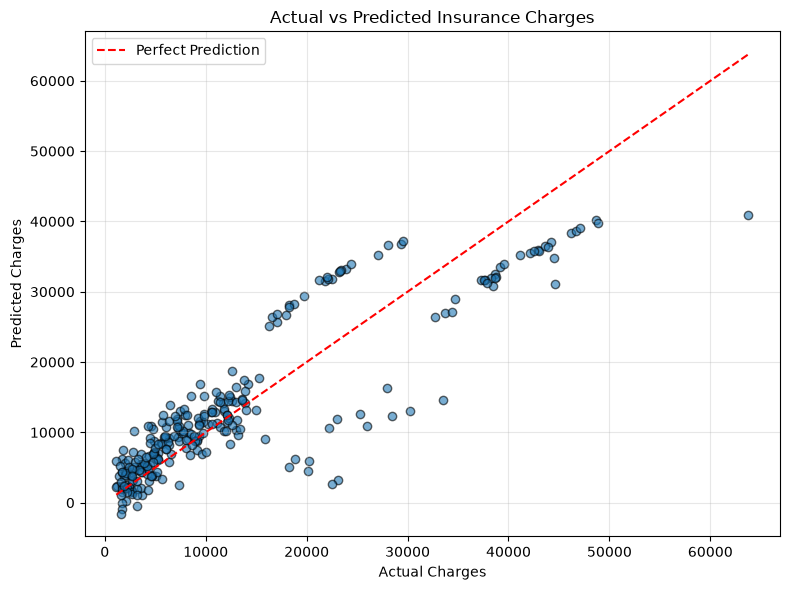

In [28]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolor="k")
plt.plot(
    [y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
    color="red", linestyle="--", label="Perfect Prediction"
)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Insurance Charges")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("actual_vs_predicted.png", dpi=150)
plt.show()

### Observations

1. The model explains ~78% of the variance in charges (R² ≈ 0.78) — a solid fit
   for a simple linear model, though a meaningful share of variance remains
   unexplained.
2. Predictions are noticeably tighter (closer to the red line) for **non-smokers**
   with lower charges, while **smokers** and high-charge outliers show much larger
   residuals — the relationship between smoking status and charges appears
   non-linear rather than proportional.
3. `smoker` has by far the largest coefficient magnitude, confirming it is the
   dominant driver of charges, followed by `age` and `bmi`; `sex` and `region`
   contribute comparatively little.

---
## Task 5: Conclusion (1 Mark)

This Multiple Linear Regression model predicts medical insurance charges using
age, sex, BMI, number of children, smoking status, and region. Smoking status
emerged as the strongest predictor, with smokers incurring substantially higher
charges than non-smokers, followed by age and BMI, both of which increase
charges as they rise. Sex and region had comparatively minor effects. The model
achieved a reasonably strong R² score on the test set, showing it captures the
broad cost drivers well, though prediction errors were larger for smokers and
high-BMI individuals, whose charges rise steeply rather than steadily.

**Limitation:** Linear Regression assumes a linear, additive relationship between
features and charges, but the real relationship — particularly the sharp jump in
cost for smokers combined with high BMI — is non-linear and interactive. This
means the model likely underfits these high-cost segments, and a technique
capable of capturing feature interactions (e.g., polynomial regression, decision
trees, or gradient boosting) could better model this data.